# Black-Scholes Model
We first compute the Black-Scholes asset pricing for options analytically. Given strike price $K$, risk-free interest rate $r$, underlying asset price $S$, time to expiration $T$, and stock volatility $\sigma$, the price $C$ for a European-style call option and price $P$ for a European-style put option are
$$
\begin{align*}
C&=SN(d_+)-KN(d_)e^{-rT}\\
P&=-SN(-d_+)+KN(-d_-)e^{-rT}
\end{align*}
$$
where
- $N(z)=(2\pi)^{-1/2}\int_{-\infty}^z\exp(-z^2/2)$ is the cumulative normal distribution
- $d_+=\frac1{\sigma\sqrt{T}}\left(\log\left(\frac{S}{K}\right)+\left(r+\frac{\sigma^2}{2}\right)T\right)$
- $d_-=d_+-\sigma\sqrt{T}$.

Differentiating this formula, we may also compute the Greeks as well. See for example [the relevant Wikipedia page](https://en.wikipedia.org/wiki/Black%E2%80%93Scholes_model#The_Options_Greeks), or [Professor Martin Haugh's notes](https://www.columbia.edu/~mh2078/FoundationsFE/BlackScholes.pdf)
|       | Call                                                | Put                                                  |
|-------|-----------------------------------------------------|------------------------------------------------------|
| Delta | $N(d_+)$                                            | $N(d_+)+1$                                           |
| Gamma | $\frac{N'(d_+)}{S\sigma\sqrt{T}}$                   | $\frac{N'(d_+)}{S\sigma\sqrt{T}}$                    |
| Vega  | $SN'(d_+)\sqrt{T}$                                  | $SN'(d_+)\sqrt{T}$                                   |
| Theta | $-\frac{SN'(d_+)\sigma}{2\sqrt{T}}-rKe^{-rT}N(d_-)$ | $-\frac{SN'(d_+)\sigma}{2\sqrt{T}}+rKe^{-rT}N(-d_-)$ |
| Rho   | $KTe^{-T}N(d_-)$                                    | $-KTe^{-T}N(-d_-)$                                  |

In [1]:
import numpy as np
import scipy

In [2]:
def theoretical_payout(K, r, T, sigma, Type = 'call', Greeks = False):
    """
Prices a European option using the Black-Scholes equation, optinally returning the Greeks as well

Parameters
----------
K: float
    Strike price
r: float
    Risk-free rate (continuously compounded)
T: float
    Time to contract maturity
sigma: float
    Volatility
Type: str
    Type of contract; either 'call' or 'put'
Greeks: bool
    Whether or not to also return a dict of the Greeks for the contract
"""
    assert Type in ['call', 'put'], "Type of contract must either be a call or a put"
    
    dplus  = 1/(sigma*np.sqrt(T))*(np.log(1/K)+(r+(sigma**2)/2)*T)
    dminus = 1/(sigma*np.sqrt(T))*(np.log(1/K)+(r-(sigma**2)/2)*T)
    
    if Type == 'call':
        value = scipy.stats.norm.cdf(dplus) - K*np.exp(-r*T)*scipy.stats.norm.cdf(dminus)
    else: # This is the value for a put
        value = -scipy.stats.norm.cdf(-dplus) + K*np.exp(-r*T)*scipy.stats.norm.cdf(-dminus)

    if not Greeks:
        return value

    greeks = {
        'delta': scipy.stats.norm.cdf(dplus) if Type == 'call' else scipy.stats.norm.cdf(dplus) - 1,
        'gamma': scipy.stats.norm.pdf(dplus) / (sigma * np.sqrt(T)),
        'vega': scipy.stats.norm.pdf(dplus) * np.sqrt(T),
        'theta': -scipy.stats.norm.pdf(dplus) * sigma / (2*np.sqrt(T)) - r * K * np.exp(-r*T) * scipy.stats.norm.cdf(dminus) if Type == 'call' else \
                 -scipy.stats.norm.pdf(dplus) * sigma / (2*np.sqrt(T)) + r * K * np.exp(-r*T) * scipy.stats.norm.cdf(-dminus),
        'rho': K * T * np.exp(-r*T) * scipy.stats.norm.cdf(dminus) if Type == 'call' else \
               -K * T * np.exp(-r*T) * scipy.stats.norm.cdf(-dminus)
    }

    return value, greeks

# Binomial Tree model
The binomial tree simulates a stock path as some number of "up steps" and "downsteps". As the number of steps grows larger, the resulting distribution approaches the geometric Brownian motion assumed by the Black-Scholes model. This can be used to simulate early exercise of American puts, which have no closed form solution for the stock value unlike European options. Note also that American calls and European calls have the same value because early excercise is never optimal for American calls.

In the Cox-Ross-Rubinstein model, the value of an up step is $u=e^{\sigma\sqrt{\Delta t}}$ and the value of a down step is $d=e^{-\sigma\sqrt{\Delta t}}=u^{-1}$. The expected value of going from one step to the next should be the same as the risk-free rate to avoid arbitrage, which gives the probability of an up-step being $p=\frac{e^{r\delta t}-d}{u-d}$.

Some of the Greeks can be computed numerically from the tree. Using the notation $V_{?}$ and $S_{?}$ to denote the option value and stock value after some number of steps, we may compute (formulas taken from [https://www.csie.ntu.edu.tw/~lyuu/finance1/2016/20160330.pdf])
$$
\begin{align*}
\Delta&\approx\frac{V_u-V_d}{S_u-S_d}\\
\Gamma&\approx\frac{\frac{V_{uu}-V_{ud}}{S_{uu}-S_{ud}}-\frac{V_{ud}-V_{dd}}{S_{ud}-S_{dd}}}{(S_{uu}-S_{dd})/2}\\
\Theta&\approx\frac{V_{ud}-V_0}{2\Delta t}
\end{align*}
$$
all of which are justified as difference quotient approximations of the appropriate derivative. Neither rho nor vega can be computed directly from the tree because the model never considers different choices of $r$ nor $\sigma$ respectively.

In [3]:
def binomial_payout(K, r, T, sigma, num_steps, style = 'american', Type = 'put', Greeks = False):
    """
Prices an American option using the a binomial tree, optinally returning the Greeks as well

Parameters
----------
K: float
    Strike price
r: float
    Risk-free rate (continuously compounded)
T: float
    Time to contract maturity
sigma: float
    Volatility
num_steps: int
    number of nodes to use in the binomial tree
style: str
    Style of contract; either 'american' or 'european'
Type: str
    Type of contract; either 'call' or 'put'
Greeks: bool
    Whether or not to also return a dict of the Greeks for the contract
"""
    assert Type in ['call', 'put'], "Type of contract must either be a call or a put"
    assert style in ['american', 'european'], "Contract style must either be american or european"
    
    dt = T / num_steps
    
    up = np.exp(sigma * np.sqrt(dt))
    down = 1 / up
    discount = np.exp(-r * dt) # The discount for going from one timestep to the previous one

    p_up = (np.exp(r*dt) - down) / (up - down)
    p_down = 1 - p_up

    # Computes down ^ (num down steps) * up  ^ (num up steps)
    # as the index of the array increase, we consider more up steps so that stock_price[0] is all down, and stock_price[-1] is all up
    stock_price = (down ** np.arange(num_steps, -1, -1)) * (up ** np.arange(0, num_steps+1))

    # The variable tree stores the value of the option given how many up steps and down steps have occurred
    # We compute this recursively, starting at the base case of expiration and then working backwards in time until we reach the start of the contract
    if Type == 'call':
        tree = np.maximum(stock_price - K, 0)
    elif Type == 'put':
        tree = np.maximum(K - stock_price, 0)
    

    if Greeks: # Create dictionary to store Greeks in
        greek_values = {}

    for i in range(num_steps-1, -1, -1):
        tree = discount * (p_down*tree[:-1] + p_up*tree[1:]) # Weighted average of the up and down steps
        if style == 'american':
            # Compute value of early exercise of contract
            # We do this for both calls and puts, and we see that exercising calls early confers no advantage, just as theory predicts
            stock_price = (down ** np.arange(i, -1, -1)) * (up ** np.arange(0, i+1))
            if Type == 'call':
                excercise_val = np.maximum(stock_price - K, 0)
            elif Type == 'put':
                excercise_val = np.maximum(K - stock_price, 0)
            tree = np.maximum(tree, excercise_val)
        if Greeks:
            if i == 1: # When only V_u and V_d remain, approximate delta
                greek_values['delta'] =  (tree[1] - tree[0]) / (up - down)
            if i == 2: # For V_uu, V_ud=V_du, and V_dd, compute the two approximations of delta for slightly different stock prices
                       # then use these to approximate Gamma
                d1 = (tree[2] - tree[1]) / ((up - down) * up)
                d2 = (tree[1] - tree[0]) / ((up - down) * down)
                greek_values['gamma'] = 2 * (d1 - d2) / (up ** 2 - down ** 2)
                theta_temp = tree[1] # We only store one time step at a time, so we need to save V_ud=V_du to compute theta
            if i == 0: # V_du represents the value of the same contract, but with a quicker expiration time, so we use it to compute theta
                greek_values['theta'] = (theta_temp - tree[0]) / (2 * dt)

    value = tree[0]
    
    if Greeks:
        # There is no way to compute rho and vega except by running the model again
        greek_values['rho'] = (binomial_payout(K, r+0.001, T, sigma, num_steps, style = style, Type = Type) - tree[0]) / 0.001
        greek_values['vega'] = (binomial_payout(K, r, T, sigma+0.001, num_steps, style = style, Type = Type) - tree[0]) / 0.001
        return (value, greek_values)
    return value

In [4]:
# Validate our binomial tree method by comparing it to exact solutions from the Black-Scholes formula
# We also see that American calls and European calls are valued identically, which is predicted by theory but not hardcoded

K = 0.95
r = 0.05
T = 1
sigma = 0.4

print(f'Option prices for K={K}, r={r}, T={T}, and sigma={sigma}')
print('Exact European call:', theoretical_payout(K, r, T, sigma))
print('Numerical European call:', binomial_payout(K, r, T, sigma, 1000, style = 'european', Type = 'call'))
print('Numerical American call:', binomial_payout(K, r, T, sigma, 1000, style = 'american', Type = 'call'))
print('-'*20)
print('Exact European put:', theoretical_payout(K, r, T, sigma, Type = 'put'))
print('Numerical European put', binomial_payout(K, r, T, sigma, 1000, style = 'european', Type = 'put'))
print('Numerical American put', binomial_payout(K, r, T, sigma, 1000, style = 'american', Type = 'put'))

Option prices for K=0.95, r=0.05, T=1, and sigma=0.4
Exact European call: 0.20379349629711718
Numerical European call: 0.20376431993619423
Numerical American call: 0.20376431993619423
--------------------
Exact European put: 0.10746144957279535
Numerical European put 0.10743227321185143
Numerical American put 0.11142581105781525


In [5]:
# Validate our Greek computations by comparing them to the exact Black-Scholes values
def print_greeks(greeks):
    for greek in ['delta', 'gamma', 'vega', 'theta', 'rho']:
        print('--', f'{greek} = {greeks[greek]}')

print('Greeks for the same parameters as the previous cells')

print('Numerical American call')
print_greeks(binomial_payout(K, r, T, sigma, 1000, Type = 'call', style = 'american', Greeks = True)[1])
for Type in ['call', 'put']:
    print(f'Exact European {Type}')
    print_greeks(theoretical_payout(K, r, T, sigma, Type = Type, Greeks = True)[1])
    print(f'Numerical European {Type}')
    print_greeks(binomial_payout(K, r, T, sigma, 1000, Type = Type, style = 'european', Greeks = True)[1])

Greeks for the same parameters as the previous cells
Numerical American call
-- delta = 0.6747983016803382
-- gamma = 0.9006231387595182
-- vega = 0.35855658944519697
-- theta = -0.0956083267548008
-- rho = 0.47124809814819146
Exact European call
-- delta = 0.6748095988387746
-- gamma = 0.9000022781133924
-- vega = 0.360000911245357
-- theta = -0.09555098737615426
-- rho = 0.4710161025416574
Numerical European call
-- delta = 0.6747983016803382
-- gamma = 0.9006231387595182
-- vega = 0.35855658944519697
-- theta = -0.0956083267548008
-- rho = 0.47124809814819146
Exact European put
-- delta = -0.32519040116122544
-- gamma = 0.9000022781133924
-- vega = 0.360000911245357
-- theta = -0.050367589712370354
-- rho = -0.43265185073402085
Numerical European put
-- delta = -0.32520169831964485
-- gamma = 0.9006231387595663
-- vega = 0.3585565894451692
-- theta = -0.05042266984579824
-- rho = -0.4319681717556978


# Implied volatility
Now that we can compute the price of American and European options, we can go backwards and work out the implied volatility given an option's price. Because we have also computed delta, we can do Newton's method to speed up convergence.

In [6]:
def implied_volatility(K, r, T, V, style = 'american', Type = 'call'):
    """
    
Computes the value of volatility that would produce the option's price under the Black-Scholes model.
We employ Newton's method until we have reached a desired level of convergence. We also use fewer nodes in the binomial tree model
until we are sufficiently close to the price in order to speed up computations.

Parameters
----------
K: float
    Strike price
r: float
    Risk-free rate (continuously compounded)
T: float
    Time to contract maturity
V: float
    Price of the contract
style: str
    Style of contract; either 'american' or 'european'
Type: str
    Type of contract; either 'call' or 'put' 
"""
    error_left = binomial_payout(K, r, T, 0.01, 100, style = style, Type = Type) - V
    error_right = binomial_payout(K, r, T, 5, 100, style = style, Type = Type) - V
    if error_left * error_right > 0: # Both have the same sign
        if np.abs(error_left) < np.abs(error_right):
            return 0.01
        else:
            return 5
    return scipy.optimize.bisect(
        lambda volatility: binomial_payout(K, r, T, volatility, 100, style = style, Type = Type) - V,
        0.01,
        5
    )

In [7]:
K = 1.01
r = 0.07
T = 2
sigma = 0.6

print('Finding implied volatility of an option with the following parameters')
print(f'K = {K}, r = {r}, T = {T}, sigma = {sigma}')

european_call = theoretical_payout(K, r, T, sigma, Type = 'call')
print('European call option price', european_call)
print('--implied volatility', implied_volatility(K, r, T, european_call, style = 'european', Type = 'call'))

european_put = theoretical_payout(K, r, T, sigma, Type = 'put')
print('European put option price', european_put)
print('--implied volatility', implied_volatility(K, r, T, european_put, style = 'european', Type = 'put'))

american_put = binomial_payout(K, r, T, sigma, 1000, Type = 'put', style = 'american')
print('American put option price', american_put)
print('--implied volatility', implied_volatility(K, r, T, american_put, style = 'american', Type = 'put'))

Finding implied volatility of an option with the following parameters
K = 1.01, r = 0.07, T = 2, sigma = 0.6
European call option price 0.37296259405188076
--implied volatility 0.600966370210674
European put option price 0.2510144118046748
--implied volatility 0.6009663702129432
American put option price 0.27137625818538613
--implied volatility 0.6004049471770418


# Oil Historical Data
Spot price historical data was gathered from https://www.eia.gov/dnav/pet/hist/RWTCD.htm, which is in turn sourced from Reuters

We will first examine the spot price history and volatility, and then look at data for oil companies

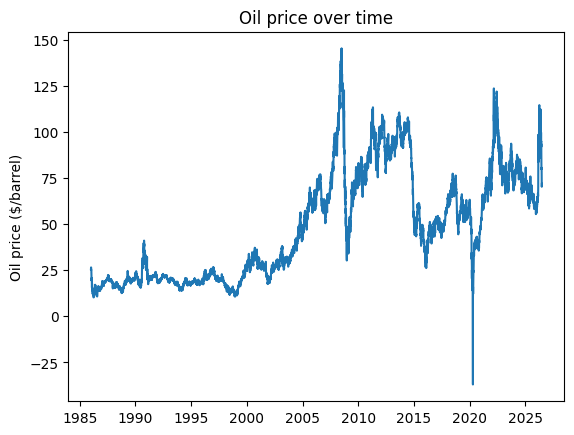

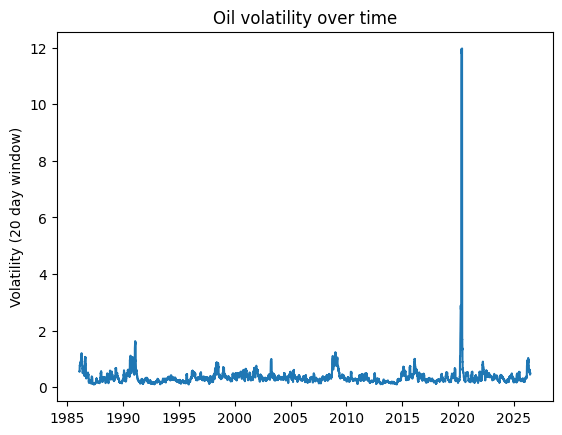

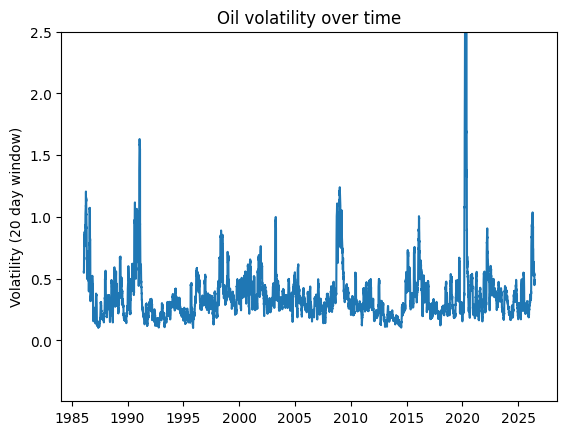

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('oil_spot.csv')
df['Day'] = pd.to_datetime(df['Day']) # Convert the day column from str to datetime

price_col = df.columns[1] # The name is rather long

df['monthly volatility'] = df[price_col][::-1].pct_change().fillna(0).rolling(20).std()[::-1]*(252) ** 0.5

plt.plot(df['Day'], df[price_col])
plt.title('Oil price over time')
plt.ylabel('Oil price ($/barrel)')
plt.show()

plt.plot(df['Day'], df['monthly volatility'].to_numpy())
plt.title('Oil volatility over time')
plt.ylabel('Volatility (20 day window)')
plt.show()

plt.plot(df['Day'], df['monthly volatility'].to_numpy())
plt.title('Oil volatility over time')
plt.ylabel('Volatility (20 day window)')
plt.ylim(top=2.5)
plt.show()

Note that there is not a mistake in the data. Oil prices in 2020 were briefly negative due to overproduction in Russia and Saudi Arabia and underconsumption due to the pandemic. As a result, people who held oil futures essentially had to pay people to deal with the oil.

# Oil Derivatives Data
Derivatives data was acquired from [Databento](https://databento.com/).

In [9]:
import yfinance as yf

[*********************100%***********************]  1 of 1 completed


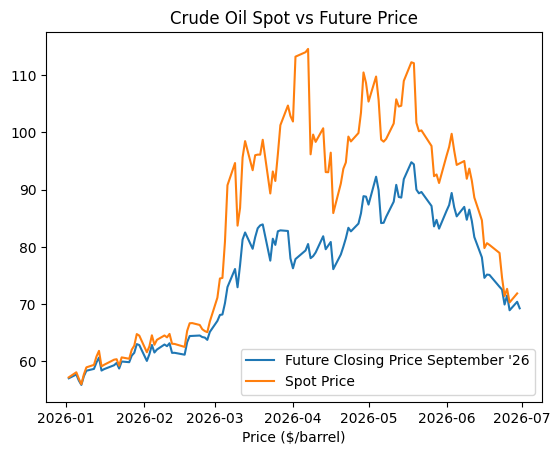

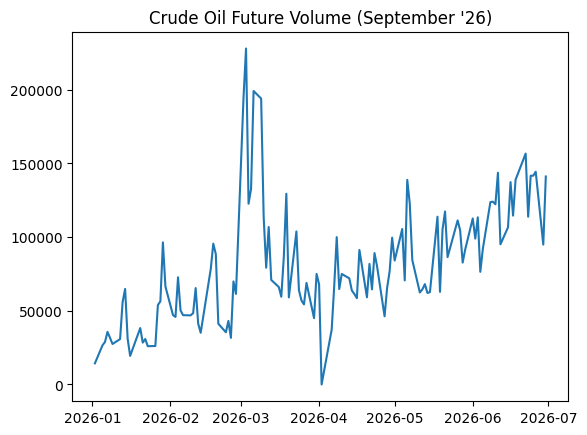

In [10]:
data = yf.download(tickers = 'CLU26.NYM', start = '2026-01-01', end = '2026-07-01')

plt.title('Crude Oil Spot vs Future Price')
plt.xlabel('Price ($/barrel)')
data_2026 = df[df['Day'].between(data.index[0], data.index[-1])]
plt.plot(data.index, data['Close', 'CLU26.NYM'], label = "Future Closing Price September '26")
plt.plot(data_2026['Day'], data_2026[price_col], label = 'Spot Price')
plt.legend()
plt.show()

plt.title("Crude Oil Future Volume (September '26)")
plt.plot(data.index, data['Volume'])
plt.show()

The spot price and future price notably diverged in March through June, which is not what is predicted by spot-future parity. This is due to abrupt liquidity difficulties during this period, which investors likely forecasted as temporary.

## Implied volatility from options
We use data from Yahoo Finance to estimate the volatility of stock prices of Occidental Petroleum Corp (OXY). Unfortunately, Yahoo Finance only includes present data for options pricing, and not historical data. Moreover, this source does not include data for options on futures for oil prices, which is why we use OXY as a stand-in for oil prices.

In [11]:
ticker_symbol = 'OXY'
stock = yf.Ticker(ticker_symbol)

cur_price = stock.fast_info.last_price

expirations = stock.options

target_date = expirations[7]
option_chain = stock.option_chain(target_date)

In [12]:
import time

historical_data = {}

for date in expirations:
    historical_data[date] = stock.option_chain(date).calls
    time.sleep(1) # Avoid rate limits

In [13]:
import datetime
from tqdm import trange

today = datetime.date.today()

strike_list = []
expiration_list = []
price_list = []
IV_list = []

for date in list(historical_data.keys())[1:]: # Skip the first one because it's so close to expiry the implied volatilities are meaningless
    expiration_date = datetime.date.strptime(date, "%Y-%m-%d")
    years = (expiration_date-today).days/365
    strikes = historical_data[date]['strike'].to_numpy()
    prices = ((historical_data[date]['bid'] + historical_data[date]['ask'])/2).to_numpy() # Average bid and ask to reduce noise
    IV = historical_data[date]['impliedVolatility'].to_numpy()
    for i in range(len(strikes)):
        if 0.8 <= strikes[i] / cur_price <= 1.2 and years >= 0.05: # Only use reasonably in the money data and contracts more than a week out
            strike_list.append(strikes[i] / cur_price)
            expiration_list.append(years)
            price_list.append(prices[i] / cur_price)
            IV_list.append(IV[i])

IV_list_manual = []
for i in trange(len(strike_list)):
    IV_list_manual.append(implied_volatility(strike_list[i], 0.04, expiration_list[i], price_list[i]))

100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:10<00:00, 11.05it/s]


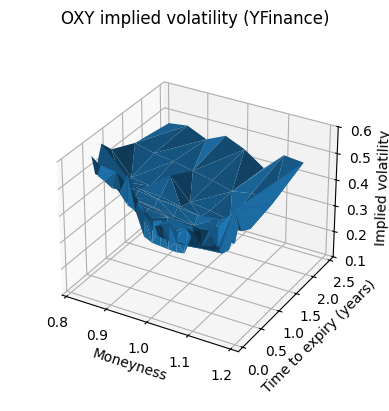

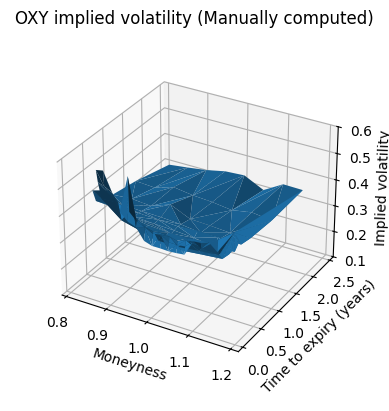

In [14]:
ax = plt.figure().add_subplot(projection = '3d')
ax.set_zlim(bottom = 0.1, top = 0.6)
ax.plot_trisurf(strike_list, expiration_list, IV_list, axlim_clip = True)
plt.title('OXY implied volatility (YFinance)')

ax.set_xlabel('Moneyness')
ax.set_ylabel('Time to expiry (years)')
ax.set_zlabel('Implied volatility')
ax.set_box_aspect(None, zoom=0.85)
plt.show()

ax = plt.figure().add_subplot(projection = '3d')
ax.set_zlim(bottom = 0.1, top = 0.6)
ax.plot_trisurf(strike_list, expiration_list, IV_list_manual, axlim_clip = True)
plt.title('OXY implied volatility (Manually computed)')

ax.set_xlabel('Moneyness')
ax.set_ylabel('Time to expiry (years)')
ax.set_zlabel('Implied volatility')
ax.set_box_aspect(None, zoom=0.85)
plt.show()



Notice that for options which expire soon, our computations line up with the data from YFinance pretty closely, and in particular show a smile for shortly expiring contracts. One source of error in our computations is we do not model stock dividends from OXY. Dividends drive down call prices, which in turn results in a smaller implied volatility for calls. The implied volatility appears to consistently be between 30%-50%, which mirrors the typical volatility we saw in the oil prices.

## Historical Oil Options
We were able to source data from [Databento](https://databento.com/) for historical prices of oil options, which are not available on Yahoo Finance. However, their license agreement prohibits disclosing such data. This also prevents us from sharing the implied volatilities, as these can be used to work out the historical options prices. As such, we regretably cannot include this data in our project